# Basic use of the oimTempGrad component

This is a basic example showing the main features of the oimBinary component:

- Creation of the component and read-out functionality
- Computing and plotting wavelength-dependent visibilities (with getComplexCoherentFlux) as well as model images
- Making final plots and saving the component in a .json file

More in detail features with data preparation and loading are shown in the `exampleOimTempGrad` script

We start by loading the required modules

In [62]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import oimodeler as oim

The **oimTempGrad** component can be defined with 8 base parameters

- `rin` : Inner radius of the disk (au)
- `rout` : Outer radius of the disk (au)
- `r0` : Reference radius for power-law (au)
- `q` : Power-law exponent of the temperature profile
- `T0` : Temperature at reference radius `r0` (K)
- `p` : Power-law exponent of the dust surface density profile
- `Mdust` : Mass of the dusty disk (M_sun)
- `kappa_abs` : Silicate absorption opacity (cm²/g)
- `dist` : Distance to the star (pc)

Optionally, by either setting `compute_sigma=False` during the component initialisation or passing

- `log_sigma0` : Logarithmic dust surface density at reference radius ``r0``

as a keyword argument, `Mdust` will be replaced by the above parameter.

Moreover, if 

- `kappa_cont` : Continuum absorption opacity (cm²/g)

is passed, then 

- `kappa_ratio` : Silicate to continuum ratio

will be set as a *free* parameter.

---
All subclasses of **oimComponentRadialProfile** (including **oimTempGrad**) have the option of activating asymmetry by passing the `asymmetric` keyword argument during initialisation. If done, there will be a number of `n` additional *free* parameters (starting from `1`):

- `skw1` : Amplitude of the modulation
- `skwPa1` : Position angle of the modulation (deg)

that determine an azimuthal asymmetry faciliatated by a Cosine modulation in the component. The `modulation_order` (i.e. `n`) can be determined by passing the keyword argument of the same name with an integer number or setting the class attribute accordingly. 

<div class="alert alert-info">

**Note:** As for all **oimComponentFourier** one can add ellipticity. This is by default on for **oimTempGrad** and can be set via

- `pa` : Positional Angle (deg)
- `elong` : Elongation

One can choose also to have a flattend component instead of an elongated one by either passing

- `cosi` : Cosine of the inclination angle

or directly passing `flat=True` (will automatically set `cosi` as a parameter with value `1` and remove `elong`)

</div>

In [23]:
data_dir = Path(globals()['_dh'][0]).parent.parent.parent / "data"
opac_file = (
    data_dir / "FSCMa_MATISSE" / "dustkappa_olivine_graphite_1_20.inp"
)
op_wl, op = np.loadtxt(opac_file, usecols=[0, 1], unpack=True)

In [25]:
tg = oim.oimTempGrad(
    dim=128,
    dist=121.0,
    T0=350,
    rin=0.1,
    rout=30,
    p=-0.58,
    q=-0.45,
    log_sigma0=-3.25,
    pa=72.52,
    cosi=0.40,
    kappa_abs=oim.oimInterp("wl", wl=op_wl * 1e-6, values=op),
)

## Plotting the model and interferometric measurements
Without external data we can compute the visibility as for any other **oimComponent** using the **getComplexCoherentFlux** method of the **oimModel** class.

We first build a oimModel containing our temperature gradientcomponent.

In [32]:
model = oim.oimModel(tg)
model.getFreeParameters()

{'c1_TempGrad_cosi': oimParam at 0x7f42c857ab10 : cosi=0.4 ± 0  range=[0.0,1.0] free=True ,
 'c1_TempGrad_pa': oimParam at 0x7f42c857aba0 : pa=72.52 ± 0 deg range=[-180.0,180.0] free=True ,
 'c1_TempGrad_rin': oimParam at 0x7f42c857ac30 : rin=0.1 ± 0 AU range=[0.0,inf] free=True ,
 'c1_TempGrad_rout': oimParam at 0x7f42c857acc0 : rout=30 ± 0 AU range=[0.0,inf] free=True ,
 'c1_TempGrad_T0': oimParam at 0x7f42c857ade0 : T0=350 ± 0 K range=[-inf,inf] free=True ,
 'c1_TempGrad_log_sigma0': oimParam at 0x7f42c857ae70 : log_sigma0=-3.25 ± 0  range=[-5,0] free=True ,
 'c1_TempGrad_q': oimParam at 0x7f42c857af00 : q=-0.45 ± 0  range=[-1,0] free=True ,
 'c1_TempGrad_p': oimParam at 0x7f42c857af90 : p=-0.58 ± 0  range=[-1,0] free=True }

To fit this model, proper (non-infinite) priors would need to be set for these free parameters in order to avoid errors with, for instance, `emcee`.
As this component is computing the temperature power-law at the reference radius `r0` with scientific interest often being directed toward the inner rim temperature, there is a property that can both read

In [39]:
Tin = tg.Tin
print(f"Tin: {Tin:.2f} K")

Tin: 986.43 K


And set `T0` from an inner rim temperature

In [41]:
tg.Tin = Tin
print(tg.T0.value)

350.0


Now we use the `oimModel.plotVis` function to show the complex coherent fluxes

(<Figure size 500x400 with 1 Axes>,
 <Axes: xlabel='B/$\\lambda$ ($\\mathrm{cycle\\,rad^{-1}}$)', ylabel='Visbility'>)

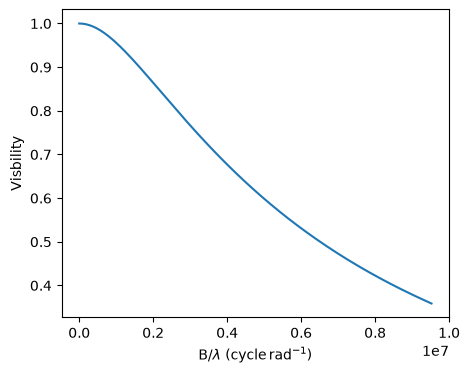

In [16]:
B, wl = np.linspace(0.0, 100, 200), 10.5e-6
model.plotVis(B, wl)

Finally, we also display the model inimage plane

(<Figure size 750x750 with 2 Axes>,
 array([[<oimAxes: xlabel='$\\alpha$ (mas)', ylabel='$\\delta$ (mas)'>]],
       dtype=object),
 array([[[[0.00322444, 0.00322429, 0.00322413, ..., 0.00071256,
           0.00071105, 0.00070954],
          [0.00324439, 0.00324426, 0.00324411, ..., 0.00071629,
           0.00071476, 0.00071324],
          [0.00326448, 0.00326436, 0.00326422, ..., 0.00072003,
           0.0007185 , 0.00071697],
          ...,
          [0.00071917, 0.00072071, 0.00072225, ..., 0.00328433,
           0.00328447, 0.0032846 ],
          [0.00071544, 0.00071697, 0.0007185 , ..., 0.00326407,
           0.00326422, 0.00326436],
          [0.00071173, 0.00071324, 0.00071476, ..., 0.00324394,
           0.00324411, 0.00324426]]]], shape=(1, 1, 1024, 1024)))

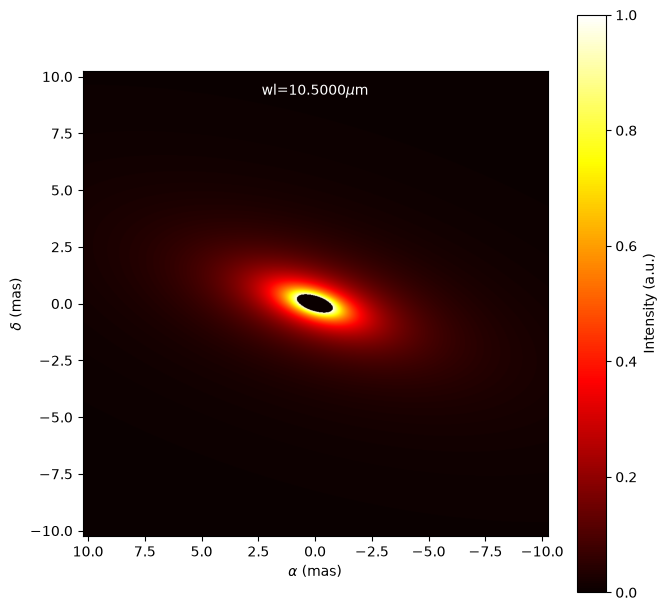

In [35]:

model.showModel(
    1024,
    pixSize=0.02,
    wl=wl,
    normalize=True,
    legend=True,
    normPow=1,
    cmap="hot",
    figsize=(7.5, 7.5),
)